In [1]:
import pandas as pd

def smooth_features(features, window_size=6):
    """
    Applies a rolling mean to features to stabilize HMM states.
    window_size=6 represents a 30-second moving average (6 * 5s).
    """
    df = pd.DataFrame(features)
    # Use Gaussian or simple rolling mean to reduce flicker
    smoothed = df.rolling(window=window_size, min_periods=1, center=False).mean()
    return smoothed.values

In [2]:
import numpy as np
from scipy.signal import welch
from antropy import perm_entropy

# Left↔Right homologous bipolar pairs (0-based indices) based on EDF channel list
# Left (1–8) pairs with Right (9–16 / 13–16) as appropriate:
PAIRS_LR = [
    (0, 12),  # ch1  FP1-F7  ↔ ch13 FP2-F8
    (1, 13),  # ch2  F7-T7   ↔ ch14 F8-T8
    (2, 14),  # ch3  T7-P7   ↔ ch15 T8-P8
    (3, 15),  # ch4  P7-O1   ↔ ch16 P8-O2
    (4, 8),   # ch5  FP1-F3  ↔ ch9  FP2-F4
    (5, 9),   # ch6  F3-C3   ↔ ch10 F4-C4
    (6, 10),  # ch7  C3-P3   ↔ ch11 C4-P4
    (7, 11),  # ch8  P3-O1   ↔ ch12 P4-O2
]

def get_advanced_state_features(epoch_data, sfreq=256):
    features = []
    eps = 1e-10
    PRIMARY_CH = list(range(18))  # ch1..ch18
    """
    Transforms 5-second EEG windows into a 6D state-space coordinate:
    1. Theta/Alpha Ratio
    2. Permutation Entropy
    3. Line Length (Spikiness)
    4. RMS Amplitude (Power)
    5. Hemispheric Synchronization
    6. Spectral Edge Frequency 95%
    """

    for window in epoch_data:
        X = window[PRIMARY_CH, :]

        freqs, psd = welch(X, sfreq, nperseg=sfreq * 2)
        th_mask = (freqs >= 4) & (freqs < 8)
        al_mask = (freqs >= 8) & (freqs < 13)
        theta = np.trapezoid(psd[:, th_mask], freqs[th_mask], axis=1).mean()
        alpha = np.trapezoid(psd[:, al_mask], freqs[al_mask], axis=1).mean()
        ta_ratio = theta / (alpha + eps)

        complexity = np.mean([perm_entropy(ch, order=4, delay=1, normalize=True) for ch in X])

        sync_scores = []
        for li, ri in PAIRS_LR:
            c = np.corrcoef(X[li], X[ri])[0, 1]
            sync_scores.append(c)
        avg_sync = np.nanmean(sync_scores)
        if not np.isfinite(avg_sync):
            avg_sync = 0.0

        line_length = np.mean(np.sum(np.abs(np.diff(X, axis=1)), axis=1))
        rms = np.mean(np.sqrt(np.mean(X**2, axis=1)))

        df = np.diff(freqs)
        df = np.r_[df, df[-1]]
        power_bins = psd * df
        cumulative_power = np.cumsum(power_bins, axis=1)
        total_power = cumulative_power[:, -1]
        sef_indices = np.argmax(cumulative_power >= 0.95 * total_power[:, None], axis=1)
        avg_sef95 = freqs[sef_indices].mean()

        features.append([ta_ratio, complexity, line_length, rms, avg_sync])

    return np.array(features)

## Epoching of the Patient 1 data  
Split the edfs into 5 minute chunks. Each edf is 1-hour long. We choose 01.edf for the baseline data and 03.edf for the data with seizure.

In [4]:
import mne
import numpy as np

# Patient 1 (chb04) EDF list from your summary
train_files = [
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_01.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_02.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_03.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_04.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_05.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_06.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_07.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_08.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_09.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_10.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_11.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_12.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_13.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_14.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_15.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_16.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_17.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_18.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_19.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_21.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_22.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_23.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_24.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_25.edf"}
]

all_features = []
lengths = []

for i, f_info in enumerate(train_files, start=1):
    path = f_info["path"]

    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    raw.rename_channels(lambda x: x.strip("."))

    # Safety: ensure we really have 256 Hz (resample if not)
    if raw.info["sfreq"] != 256:
        raw.resample(256, npad="auto", verbose=False)

    raw.filter(1.0, 40.0, fir_design="firwin", verbose=False)
    raw.notch_filter(freqs=[60], verbose=False)

    # 5s fixed-length epochs
    epochs = mne.make_fixed_length_epochs(raw, duration=5.0, preload=True, verbose=False)
    data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)

    feats = get_advanced_state_features(data, sfreq=int(raw.info["sfreq"]))
    all_features.append(feats)
    lengths.append(len(feats))

    if i % 5 == 0 or i == len(train_files):
        print(f"Loaded {i}/{len(train_files)} files; last epochs={len(feats)}")

print("Loading complete.")


/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.

Loaded 5/24 files; last epochs=1907


/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.

Loaded 10/24 files; last epochs=2880


/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.

Loaded 15/24 files; last epochs=2880


/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.

Loaded 20/24 files; last epochs=2880


/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/v5/fl3p2mv95pn6b5w09z_mbpf40000gn/T/ipykernel_41183/2541890991.py:38: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.

Loaded 24/24 files; last epochs=2880
Loading complete.


In [65]:
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm

# 1. Scale and Smooth each file INDIVIDUALLY
# This prevents the 'loudness' of File 01 from being compared to File 03
processed_all_features = []

for f_features in all_features:
    # A. Scale this specific file to its own mean/std
    scaler_local = StandardScaler()
    feat_local_scaled = scaler_local.fit_transform(f_features)
    
    # B. Smooth the normalized data
    # (Using your existing smooth_features function)
    feat_local_smoothed = smooth_features(feat_local_scaled, window_size=6)
    
    processed_all_features.append(feat_local_smoothed)

# 2. Re-combine (Stack) and PCA
# We don't need another StandardScaler here because they are already Z-scored
feat_stack_final = np.vstack(processed_all_features)

#pca = PCA(n_components=3)
#obs_for_hmm_final = pca.fit_transform(feat_stack_final)

obs_for_hmm_final = feat_stack_final

# 3. Re-train HMM
model = hmm.GaussianHMM(
    n_components=3, 
    covariance_type="diag", 
    n_iter=2000, 
    random_state=42
)
model.fit(obs_for_hmm_final, lengths =lengths)

print("Properly Scaled & Smoothed HMM Training Complete.")

Properly Scaled & Smoothed HMM Training Complete.


Transition Probability Matrix:
         State 0  State 1  State 2
State 0   0.9499   0.0073   0.0429
State 1   0.0260   0.9194   0.0546
State 2   0.0422   0.0187   0.9391


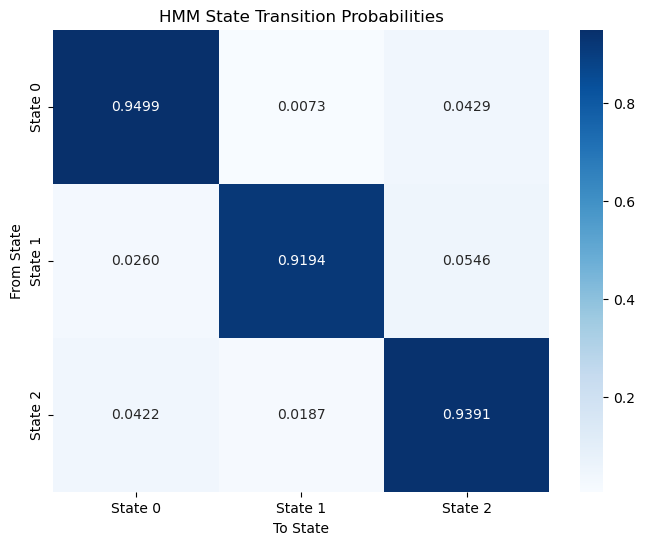

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# The matrix itself
trans_matrix = model.transmat_

# Create a clean DataFrame for viewing
state_labels = ["State 0", "State 1", "State 2"]
df_trans = pd.DataFrame(trans_matrix, columns=state_labels, index=state_labels)

print("Transition Probability Matrix:")
print(df_trans.round(4))

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(df_trans, annot=True, cmap='Blues', fmt='.4f')
plt.title("HMM State Transition Probabilities")
plt.xlabel("To State")
plt.ylabel("From State")
plt.show()

In [67]:
feature_names = ["TA_ratio", "PermEntropy", "LineLength", "RMS", "Avg Sync"]

for i in range(model.n_components):
    print(f"\nState {i} means:")
    for name, val in zip(feature_names, model.means_[i]):
        print(f"  {name:<12}: {val:+.3f}")



State 0 means:
  TA_ratio    : -0.446
  PermEntropy : +0.115
  LineLength  : -0.416
  RMS         : -0.607
  Avg Sync    : -0.043

State 1 means:
  TA_ratio    : +0.529
  PermEntropy : +0.782
  LineLength  : +1.121
  RMS         : +0.709
  Avg Sync    : -0.636

State 2 means:
  TA_ratio    : +0.276
  PermEntropy : -0.374
  LineLength  : +0.051
  RMS         : +0.380
  Avg Sync    : +0.252


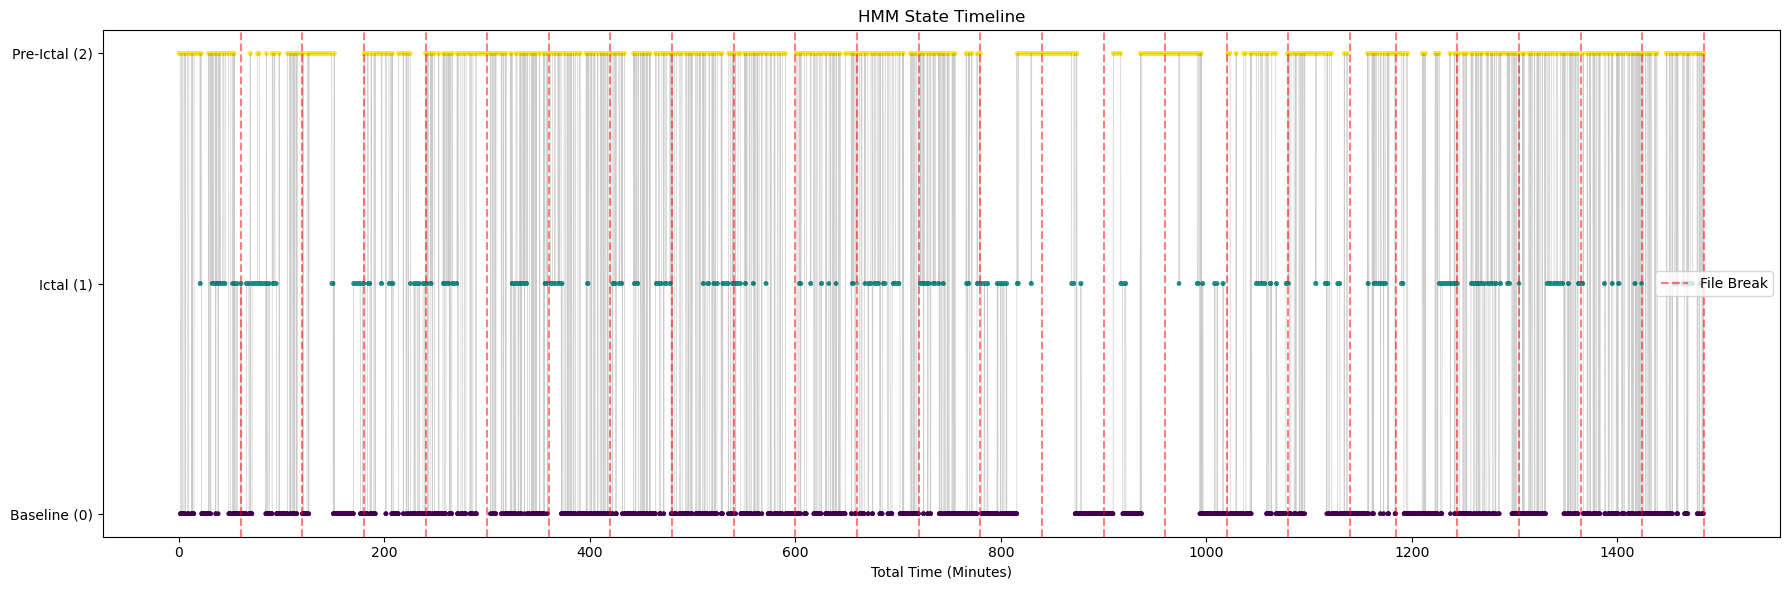

In [68]:
# === Predict hidden states (respect file boundaries) ===
hidden_states = model.predict(obs_for_hmm_final, lengths=lengths)

# === Plot timeline ===
WINDOW_SEC = 5.0  # explicit for safety
time_axis = np.arange(len(hidden_states)) * WINDOW_SEC / 60.0  # minutes

plt.figure(figsize=(18, 6))
plt.scatter(time_axis, hidden_states, c=hidden_states, cmap='viridis', s=5, alpha=0.5)
plt.plot(time_axis, hidden_states, color='black', linewidth=0.5, alpha=0.2)

# === Mark file boundaries ===
current_min = 0.0
for k, length in enumerate(lengths):
    current_min += (length * WINDOW_SEC / 60.0)
    plt.axvline(
        x=current_min,
        color='red',
        linestyle='--',
        alpha=0.5,
        label='File Break' if k == 0 else None
    )
plt.legend()

# === Derive state labels from feature-space means ===
# Feature order:
# [0] TA_ratio, [1] PermEntropy,
# [2] LineLength, [3] RMS

IDX_ENT = 1
IDX_LINELEN = 2
IDX_RMS = 3

# Ictal: high line length + high RMS
ictal_score = model.means_[:, IDX_LINELEN] + model.means_[:, IDX_RMS]
ictal_state = int(np.argmax(ictal_score))

# Baseline: highest entropy among remaining states
remaining_states = [s for s in range(model.n_components) if s != ictal_state]
baseline_state = int(
    remaining_states[np.argmax(model.means_[remaining_states, IDX_ENT])]
)

# Pre-ictal: whatever state is left (for 3-state HMM)
preictal_state = int(
    [s for s in range(model.n_components)
     if s not in (ictal_state, baseline_state)][0]
)

label_map = {
    baseline_state: "Baseline",
    preictal_state: "Pre-Ictal",
    ictal_state: "Ictal"
}

yticklabels = [
    f"{label_map[s]} ({s})" for s in range(model.n_components)
]

plt.yticks(range(model.n_components), yticklabels)

plt.xlabel("Total Time (Minutes)")
plt.title("HMM State Timeline")
plt.tight_layout()
plt.show()


In [69]:
import os
import numpy as np

WINDOW_SEC = 5.0  # keep consistent with epoch duration

# Expect these from ln[42]:
# - label_map: {state_id: "Baseline"/"Pre-Ictal"/"Ictal"}
# - hidden_states
# - lengths
# - train_files

current_idx = 0

print(f"{'Filename':<15} | {'State':<10} | {'Start (sec)':<12} | {'End (sec)':<12}")
print("-" * 60)

for i, length in enumerate(lengths):
    file_states = hidden_states[current_idx : current_idx + length]
    filename = os.path.basename(train_files[i]["path"])

    # indices where state changes (boundary starts at these indices)
    transitions = np.where(np.diff(file_states) != 0)[0] + 1
    endpoints = np.concatenate(([0], transitions, [length]))

    for j in range(len(endpoints) - 1):
        start_win = int(endpoints[j])
        end_win = int(endpoints[j + 1])
        state = int(file_states[start_win])

        start_sec = start_win * WINDOW_SEC
        end_sec = end_win * WINDOW_SEC

        state_label = label_map.get(state, f"State {state}")

        # Print only Pre-Ictal and Ictal segments
        if state_label in ("Pre-Ictal", "Ictal"):
            print(f"{filename:<15} | {state_label:<10} | {start_sec:<12.0f} | {end_sec:<12.0f}")

    current_idx += length

Filename        | State      | Start (sec)  | End (sec)   
------------------------------------------------------------
chb04_01.edf    | Pre-Ictal  | 0            | 80          
chb04_01.edf    | Pre-Ictal  | 145          | 205         
chb04_01.edf    | Pre-Ictal  | 295          | 360         
chb04_01.edf    | Pre-Ictal  | 385          | 510         
chb04_01.edf    | Pre-Ictal  | 575          | 725         
chb04_01.edf    | Pre-Ictal  | 765          | 795         
chb04_01.edf    | Pre-Ictal  | 880          | 1225        
chb04_01.edf    | Ictal      | 1225         | 1255        
chb04_01.edf    | Pre-Ictal  | 1255         | 1320        
chb04_01.edf    | Pre-Ictal  | 1725         | 1745        
chb04_01.edf    | Pre-Ictal  | 1760         | 1840        
chb04_01.edf    | Pre-Ictal  | 1865         | 1925        
chb04_01.edf    | Ictal      | 1925         | 1940        
chb04_01.edf    | Pre-Ictal  | 1940         | 1990        
chb04_01.edf    | Ictal      | 1990         | 2040    

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

WINDOW_SEC = 5.0
DENSITY_MIN = 20.0
W = int((DENSITY_MIN * 60.0) / WINDOW_SEC)  # 10 minutes -> 120 windows

# --- Identify which numeric states are Pre-Ictal and Ictal ---
pre_state = next(s for s, name in label_map.items() if name == "Pre-Ictal")
ictal_state = next(s for s, name in label_map.items() if name == "Ictal")

# --- Rolling pre-ictal density (causal) over last W windows ---
pre_indicator = (hidden_states == pre_state).astype(float)
kernel = np.ones(W, dtype=float)
pre_density = np.convolve(pre_indicator, kernel, mode="full")[:len(pre_indicator)] / W
# fix startup so early points are averaged over fewer samples (optional but nicer)
for i in range(min(W-1, len(pre_density))):
    pre_density[i] *= W / (i+1)

# --- Build a global time axis in minutes ---
t_min = (np.arange(len(hidden_states)) * WINDOW_SEC) / 60.0

# --- Build file offsets (start time in windows/minutes for each file in the concatenated series) ---
file_start_win = np.cumsum([0] + lengths[:-1])
file_start_min = file_start_win * WINDOW_SEC / 60.0

# --- Clinical seizure annotations you provided (seconds-from-file-start) ---
# Only for the seizure files here; extend as needed.
clinical = {
    "chb04_05.edf": [(7804, 7853)],
    "chb04_08.edf": [(6446, 6557)]
}

# --- Plot ---
plt.figure(figsize=(18, 6))

# Pre-ictal density line + light fill
plt.plot(t_min, pre_density, linewidth=2, label=f"Pre-Ictal Density ({int(DENSITY_MIN)}m Window)")
plt.fill_between(t_min, 0, pre_density, alpha=0.15)

# Shade predicted ictal windows
ictal_mask = (hidden_states == ictal_state)
plt.fill_between(t_min, 0, 1, where=ictal_mask, alpha=0.12, label="Predicted Ictal State")

# File breaks
for k, startm in enumerate(file_start_min[1:]):  # skip first at 0
    plt.axvline(x=startm, color="gray", linestyle=":", alpha=0.6, label="File Break" if k == 0 else None)

# Clinical seizure start/end markers
# Convert per-file seconds to global minutes using file offset
seen_label_start = False
seen_label_end = False

for i, f in enumerate(train_files):
    fname = os.path.basename(f["path"])
    if fname not in clinical:
        continue
    base_min = file_start_min[i]
    for (s0, s1) in clinical[fname]:
        x0 = base_min + (s0 / 60.0)
        x1 = base_min + (s1 / 60.0)
        plt.axvline(x=x0, color="red", linestyle="--", linewidth=2, alpha=0.9,
                    label="Clinical Seizure Start" if not seen_label_start else None)
        plt.axvline(x=x1, color="red", linestyle="-.", linewidth=2, alpha=0.9,
                    label="Clinical Seizure End" if not seen_label_end else None)
        seen_label_start = True
        seen_label_end = True

plt.ylim(0, 1.05)
plt.xlabel("Time (Total Minutes)")
plt.ylabel("Pre-Ictal Density (fraction of last 10 min)")
plt.title("Pre-Ictal Density (10m) with Predicted Ictal and Clinical Seizure Annotations")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


NameError: name 'label_map' is not defined